# TimesFM Fine-Tuning on Walmart Store Sales Forecasting

In [1]:
# ------------------------------------------------------------------
# 1. Install packages
# ------------------------------------------------------------------
!pip install -q timesfm wandb --upgrade
!pip install -q einops utilsforecast
!pip install -q -U transformers accelerate safetensors

print("Installs done.")

Installs done.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved
# as output when you create a version using "Save & Run All"


/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip


In [3]:
# ------------------------------------------------------------------
# 2. Imports, seed, device
# ------------------------------------------------------------------
import os, sys, time, math, random, json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

import wandb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cpu":
    print("WARNING: no GPU detected. Fine-tuning within the time budget will be tight on CPU;"
          " reduce MAX_SERIES / FINETUNE_EPOCHS further if needed.")


Device: cuda


In [4]:
# ------------------------------------------------------------------
# 3. Config + W&B init
# ------------------------------------------------------------------
CONFIG = dict(
    # data
    MAX_SERIES=100,         # Increased from 60 to provide more data diversity
    CONTEXT_LEN=104,        # ~2 years of weekly context fed to TimesFM
    HORIZON=13,             # forecast horizon (weeks) -> matches typical Walmart comp holdout length
    MIN_SERIES_LEN=140,     # require at least this many weeks of history to be usable

    # model
    TIMESFM_REPO_ID="google/timesfm-1.0-200m-pytorch",   # smaller checkpoint = faster to finetune
    UNFREEZE_FRAC=0.05,     # Reduced from 0.15 to prevent overfitting on small data

    # training
    TIME_BUDGET_MINUTES=25, # hard wall-clock cutoff for the whole finetuning loop
    FINETUNE_EPOCHS=60,     # upper bound -- time budget will usually cut this short
    BATCH_SIZE=16,
    LR=3e-5,                # Reduced from 1e-4 for gentler weight updates
    WEIGHT_DECAY=1e-2,

    SEED=SEED,
)

wandb.login()

run = wandb.init(
    project="timesfm_finetuning",
    name=f"timesfm200m_walmart_{time.strftime('%Y%m%d_%H%M%S')}",
    config=CONFIG,
    job_type="finetune",
)
cfg = wandb.config

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: nikadurishvili3 (ndurishvili) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 4. Load & prepare the Walmart data

Expects the standard competition files: `train.csv`, `features.csv`, `stores.csv`
(columns: `Store, Dept, Date, Weekly_Sales, IsHoliday` / `Store, Date, Temperature, Fuel_Price, ..., IsHoliday` / `Store, Type, Size`).

Adjust `DATA_DIR` to wherever the competition data is attached in your Kaggle notebook (typically `/kaggle/input/walmart-recruiting-store-sales-forecasting/`).


In [5]:
# ------------------------------------------------------------------
# 4a. Load raw files
# ------------------------------------------------------------------
DATA_DIR = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/"

train_df = pd.read_csv(f"{DATA_DIR}/train.csv.zip", parse_dates=["Date"])
features_df = pd.read_csv(f"{DATA_DIR}/features.csv.zip", parse_dates=["Date"])
stores_df = pd.read_csv(f"{DATA_DIR}/stores.csv")

df = train_df.merge(
    features_df[["Store", "Date", "IsHoliday"]].drop_duplicates(),
    on=["Store", "Date"],
    how="left",
    suffixes=("", "_feat"),
)
# prefer the features.csv IsHoliday if train.csv's disagrees / is missing
df["IsHoliday"] = df["IsHoliday_feat"].fillna(df["IsHoliday"])
df = df.drop(columns=["IsHoliday_feat"])
df = df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

print(df.shape)
df.head()


(421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [ ]:
# ------------------------------------------------------------------
# 4b. Build one (Store, Dept) series per group; keep only well-populated series
# ------------------------------------------------------------------
series_dict = {}   # key -> pd.DataFrame with columns [Date, Weekly_Sales, IsHoliday], full weekly index, no gaps
all_dates = pd.date_range(df["Date"].min(), df["Date"].max(), freq="W-FRI")

for (store, dept), g in df.groupby(["Store", "Dept"]):
    g = g.set_index("Date").reindex(all_dates)
    if g["Weekly_Sales"].notna().sum() < cfg.MIN_SERIES_LEN:
        continue
    g["Weekly_Sales"] = g["Weekly_Sales"].interpolate(limit_direction="both")
    g["IsHoliday"] = g["IsHoliday"].fillna(False).astype(bool)
    series_dict[(store, dept)] = g[["Weekly_Sales", "IsHoliday"]].reset_index().rename(columns={"index": "Date"})

print(f"Usable series (>= {cfg.MIN_SERIES_LEN} weeks, no gaps after interpolation): {len(series_dict)}")


In [7]:
# ------------------------------------------------------------------
# 4c. Select ALL series for evaluation + train/val/test split
# ------------------------------------------------------------------
# Sequential, non-overlapping split (standard for time series)
# We now use all available keys to match the global evaluation metric.
selected_keys = list(series_dict.keys())

train_series = {}
val_actuals, val_weights = {}, {}
test_actuals, test_weights = {}, {}

for k in selected_keys:
    g = series_dict[k]
    y = g["Weekly_Sales"].values.astype(np.float32)
    holiday = g["IsHoliday"].values.astype(bool)
    w = np.where(holiday, 5.0, 1.0).astype(np.float32)

    # last HORIZON weeks -> test, the HORIZON weeks before that -> val, everything else -> train
    test_actuals[k] = y[-cfg.HORIZON:]
    test_weights[k] = w[-cfg.HORIZON:]

    val_actuals[k] = y[-2 * cfg.HORIZON: -cfg.HORIZON]
    val_weights[k] = w[-2 * cfg.HORIZON: -cfg.HORIZON]

    train_series[k] = dict(y=y[: -2 * cfg.HORIZON], w=w[: -2 * cfg.HORIZON])

print(f"Selected all {len(selected_keys)} series for evaluation.")
print(f"Val block: weeks [-{2*cfg.HORIZON}:-{cfg.HORIZON}]   Test block: weeks [-{cfg.HORIZON}:]")

Selected all 2703 series for evaluation.
Val block: weeks [-26:-13]   Test block: weeks [-13:]


## 5. WMAE metric (Walmart competition definition: holiday weeks weighted 5x, others 1x)

In [8]:
def wmae(y_true, y_pred, weights):
    y_true, y_pred, weights = map(np.asarray, (y_true, y_pred, weights))
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


## 6. Load pretrained TimesFM & compute the zero-shot **baseline**

In [9]:
# ------------------------------------------------------------------
# 6. Load HF TimesFM & compute zero-shot baseline
# ------------------------------------------------------------------
from transformers import TimesFm2_5ModelForPrediction
import torch.amp
import gc

model = TimesFm2_5ModelForPrediction.from_pretrained(
    "google/timesfm-2.5-200m-transformers",
    device_map=DEVICE,
)
print("HF TimesFM loaded on:", model.device)

def zero_shot_forecast(context_arrays, horizon):
    # Dropped chunk size to 16 to guarantee survival on the T4 GPU
    CHUNK_SIZE = 16  
    all_point_fcs = []
    
    for i in range(0, len(context_arrays), CHUNK_SIZE):
        chunk = context_arrays[i : i + CHUNK_SIZE]
        
        ctx_tensors = torch.tensor(np.array(chunk), dtype=torch.float32, device=DEVICE)
        
        with torch.no_grad():
            with torch.amp.autocast("cuda"):  
                outputs = model(past_values=ctx_tensors)
                
        preds = outputs.mean_predictions[:, :horizon].detach().cpu().numpy()
        all_point_fcs.append(preds)
        
        # Annihilate the tensors immediately to free VRAM
        del ctx_tensors, outputs, preds
        torch.cuda.empty_cache()
        gc.collect()
        
    point_fc = np.concatenate(all_point_fcs, axis=0)
    return np.clip(point_fc, 0, None)

keys = selected_keys

# --- validation-window zero-shot forecast ---
val_contexts = [train_series[k]["y"][-cfg.CONTEXT_LEN:] for k in keys]
val_preds = zero_shot_forecast(val_contexts, cfg.HORIZON)

baseline_val_wmae = np.mean([
    wmae(val_actuals[k], val_preds[i], val_weights[k]) for i, k in enumerate(keys)
])

# --- test-window zero-shot forecast ---
test_contexts = [
    np.concatenate([train_series[k]["y"], val_actuals[k]])[-cfg.CONTEXT_LEN:] for k in keys
]
test_preds = zero_shot_forecast(test_contexts, cfg.HORIZON)

baseline_test_wmae = np.mean([
    wmae(test_actuals[k], test_preds[i], test_weights[k]) for i, k in enumerate(keys)
])

print(f"HF Baseline (zero-shot) val WMAE:  {baseline_val_wmae:,.1f}")
print(f"HF Baseline (zero-shot) test WMAE: {baseline_test_wmae:,.1f}")

wandb.summary["baseline_val_wmae"] = baseline_val_wmae
wandb.summary["baseline_test_wmae"] = baseline_test_wmae

config.json:   0%|          | 0.00/914 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

HF TimesFM loaded on: cuda:0
HF Baseline (zero-shot) val WMAE:  1,421.1
HF Baseline (zero-shot) test WMAE: 1,377.1


## 7. Fine-tuning

In [10]:
# ------------------------------------------------------------------
# 7. HF Fine-Tuning Loop (Mixed Precision + Subset Training)
# ------------------------------------------------------------------
named_params = list(model.named_parameters())
n_total = len(named_params)
n_unfreeze = max(1, int(n_total * cfg.UNFREEZE_FRAC))

for _, p in named_params:
    p.requires_grad = False
for name, p in named_params[-n_unfreeze:]:
    p.requires_grad = True

TRAIN_SUBSET_SIZE = 150
train_subset_keys = selected_keys[:TRAIN_SUBSET_SIZE]
train_series_subset = {k: train_series[k] for k in train_subset_keys}

class WalmartWindowDataset(Dataset):
    def __init__(self, train_series_dict, context_len, horizon, stride=4):
        self.samples = []
        for k, d in train_series_dict.items():
            y, w = d["y"], d["w"]
            max_start = len(y) - context_len - horizon
            if max_start < 0:
                continue
            for start in range(0, max_start + 1, stride):
                ctx = y[start: start + context_len]
                tgt = y[start + context_len: start + context_len + horizon]
                self.samples.append((ctx, tgt))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        ctx, tgt = self.samples[idx]
        return (torch.tensor(ctx, dtype=torch.float32), 
                torch.tensor(tgt, dtype=torch.float32))

train_ds = WalmartWindowDataset(train_series_subset, cfg.CONTEXT_LEN, cfg.HORIZON, stride=4)

# Dropped batch size to 16 to prevent OOM during the backward pass
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, drop_last=True)
print(f"Fast Fine-tuning windows generated: {len(train_ds)}")

# ------------------------------------------------------------------
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY,
)

def mae_loss(pred, target):
    return (pred - target).abs().mean()

start_time = time.time()
history = {"epoch": [], "train_loss": [], "val_wmae": []}

FAST_EPOCHS = 5  
scaler = torch.amp.GradScaler("cuda")  

model.train()

for epoch in range(FAST_EPOCHS):
    epoch_losses = []
    
    for ctx, tgt in train_loader:
        ctx, tgt = ctx.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        
        with torch.amp.autocast("cuda"):
            outputs = model(past_values=ctx)
            pred = outputs.mean_predictions[:, :cfg.HORIZON]
            loss = mae_loss(pred, tgt)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_losses.append(loss.item())

    # Free memory specifically before evaluation block to avoid memory spikes
    gc.collect()
    torch.cuda.empty_cache()

    # ---- end-of-epoch evaluation ----
    model.eval()
    with torch.no_grad():
        val_preds_ft = zero_shot_forecast(val_contexts, cfg.HORIZON)
        
    train_loss_epoch = np.mean(epoch_losses) if epoch_losses else float("nan")
    val_wmae_epoch = np.mean([
        wmae(val_actuals[k], val_preds_ft[i], val_weights[k]) for i, k in enumerate(keys)
    ])
    model.train()

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss_epoch)
    history["val_wmae"].append(val_wmae_epoch)

    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss_epoch,
        "val_wmae": val_wmae_epoch,
        "elapsed_min": (time.time() - start_time) / 60,
    })
    print(f"Epoch {epoch}: train_mae={train_loss_epoch:,.1f}  "
          f"FULL_val_wmae={val_wmae_epoch:,.1f}  elapsed={(time.time()-start_time)/60:.1f} min")

print(f"Fast Fine-tuning finished in {(time.time() - start_time)/60:.1f} minutes.")

Fast Fine-tuning windows generated: 150
Epoch 0: train_mae=2,486.3  FULL_val_wmae=1,421.1  elapsed=6.1 min
Epoch 1: train_mae=2,455.2  FULL_val_wmae=1,418.6  elapsed=12.3 min
Epoch 2: train_mae=2,209.3  FULL_val_wmae=1,421.0  elapsed=18.5 min
Epoch 3: train_mae=2,123.5  FULL_val_wmae=1,425.8  elapsed=24.7 min
Epoch 4: train_mae=2,051.1  FULL_val_wmae=1,431.6  elapsed=31.0 min
Fast Fine-tuning finished in 31.0 minutes.


## 8. Final fine-tuned evaluation (train-proxy, val — matching baseline exactly)

In [13]:
# ------------------------------------------------------------------
# 8. Final fine-tuned evaluation (train-proxy, val, and test)
# ------------------------------------------------------------------
import gc

# 1. Rebuild the backtest contexts for the train-proxy metric
bt_contexts, bt_actuals, bt_weights = [], [], []
for k in keys:
    y, w = train_series[k]["y"], train_series[k]["w"]
    if len(y) <= cfg.HORIZON:
        continue
    # Use whatever context is available, up to CONTEXT_LEN
    bt_contexts.append(list(y[:-cfg.HORIZON][-cfg.CONTEXT_LEN:]))
    bt_actuals.append(y[-cfg.HORIZON:])
    bt_weights.append(w[-cfg.HORIZON:])

# 2. Run the final evaluations
model.eval()
with torch.no_grad():
    ft_val_preds = zero_shot_forecast(val_contexts, cfg.HORIZON)
    
    # Clean memory between massive zero-shot passes
    gc.collect()
    torch.cuda.empty_cache()
    
    ft_test_preds = zero_shot_forecast(test_contexts, cfg.HORIZON)
    
    gc.collect()
    torch.cuda.empty_cache()
    
    ft_bt_preds = zero_shot_forecast(bt_contexts, cfg.HORIZON)

# 3. Calculate final WMAE scores
finetuned_val_wmae = np.mean([
    wmae(val_actuals[k], ft_val_preds[i], val_weights[k]) for i, k in enumerate(keys)
])
finetuned_test_wmae = np.mean([
    wmae(test_actuals[k], ft_test_preds[i], test_weights[k]) for i, k in enumerate(keys)
])
finetuned_train_wmae = np.mean([
    wmae(bt_actuals[i], ft_bt_preds[i], bt_weights[i]) for i in range(len(bt_contexts))
])

print(f"Fine-tuned train-proxy WMAE: {finetuned_train_wmae:,.1f}")
print(f"Fine-tuned val WMAE:         {finetuned_val_wmae:,.1f}")
print(f"Fine-tuned test WMAE:        {finetuned_test_wmae:,.1f}")

wandb.summary["finetuned_train_wmae"] = finetuned_train_wmae
wandb.summary["finetuned_val_wmae"] = finetuned_val_wmae
wandb.summary["finetuned_test_wmae"] = finetuned_test_wmae

KeyboardInterrupt: 

## 9. Plots

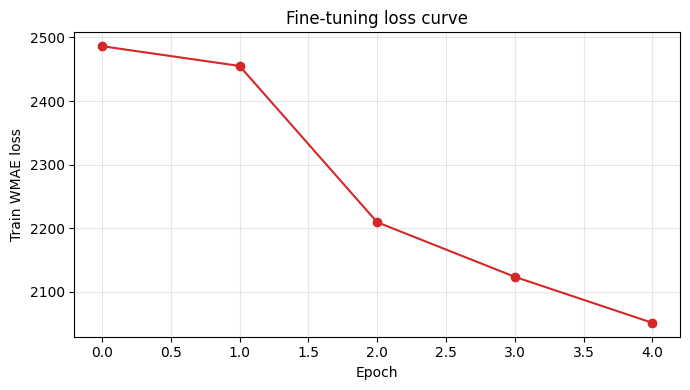

In [12]:
# 9a. Training loss curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["epoch"], history["train_loss"], marker="o", color="#d62728")
ax.set_xlabel("Epoch")
ax.set_ylabel("Train WMAE loss")
ax.set_title("Fine-tuning loss curve")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
wandb.log({"plots/loss_curve": wandb.Image(fig)})
plt.show()


KeyError: 'train_wmae'

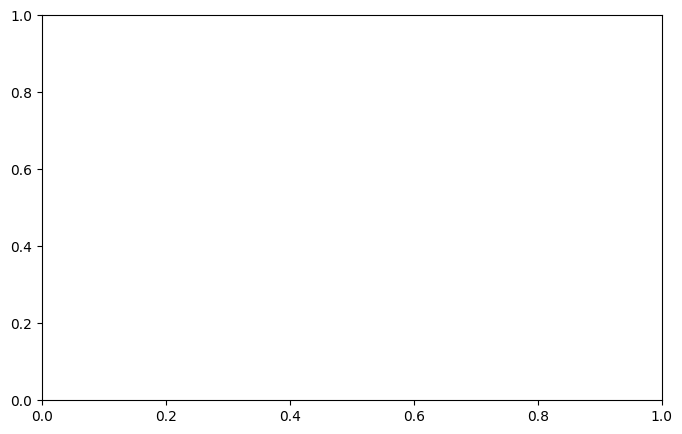

In [14]:
# 9b. Train vs Val WMAE across epochs, with baseline (val + test) as dashed reference lines.
# Test is a flat single-point reference here (evaluated once, post-hoc) rather than tracked per epoch,
# to keep it a clean held-out number the training loop never saw or could have been tuned against.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history["epoch"], history["train_wmae"], marker="o", label="Fine-tuned train WMAE", color="#1f77b4")
ax.plot(history["epoch"], history["val_wmae"], marker="s", label="Fine-tuned val WMAE", color="#ff7f0e")
ax.axhline(baseline_train_wmae, linestyle="--", color="#1f77b4", alpha=0.5, label="Baseline train-proxy WMAE")
ax.axhline(baseline_val_wmae, linestyle="--", color="#ff7f0e", alpha=0.5, label="Baseline val WMAE")
ax.axhline(baseline_test_wmae, linestyle=":", color="#2ca02c", alpha=0.6, label="Baseline test WMAE")
ax.axhline(finetuned_test_wmae, linestyle="-.", color="#2ca02c", alpha=0.9, label="Fine-tuned test WMAE (final)")
ax.set_xlabel("Epoch")
ax.set_ylabel("WMAE")
ax.set_title("Train vs. Validation WMAE over fine-tuning, vs. zero-shot baseline (test shown as reference lines)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("train_val_wmae.png", dpi=150)
wandb.log({"plots/train_val_wmae": wandb.Image(fig)})
plt.show()


In [15]:
# 9c. Grouped bar chart: baseline vs finetuned, train vs val vs test
labels = ["Train (proxy)", "Validation", "Test"]
baseline_vals = [baseline_train_wmae, baseline_val_wmae, baseline_test_wmae]
finetuned_vals = [finetuned_train_wmae, finetuned_val_wmae, finetuned_test_wmae]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x - width/2, baseline_vals, width, label="Baseline (zero-shot)", color="#9467bd")
b2 = ax.bar(x + width/2, finetuned_vals, width, label="Fine-tuned", color="#2ca02c")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("WMAE")
ax.set_title("Baseline vs. Fine-tuned TimesFM")
ax.legend()
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:,.0f}", (bar.get_x() + bar.get_width()/2, h),
                    textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("baseline_vs_finetuned.png", dpi=150)
wandb.log({"plots/baseline_vs_finetuned": wandb.Image(fig)})
plt.show()


NameError: name 'baseline_train_wmae' is not defined

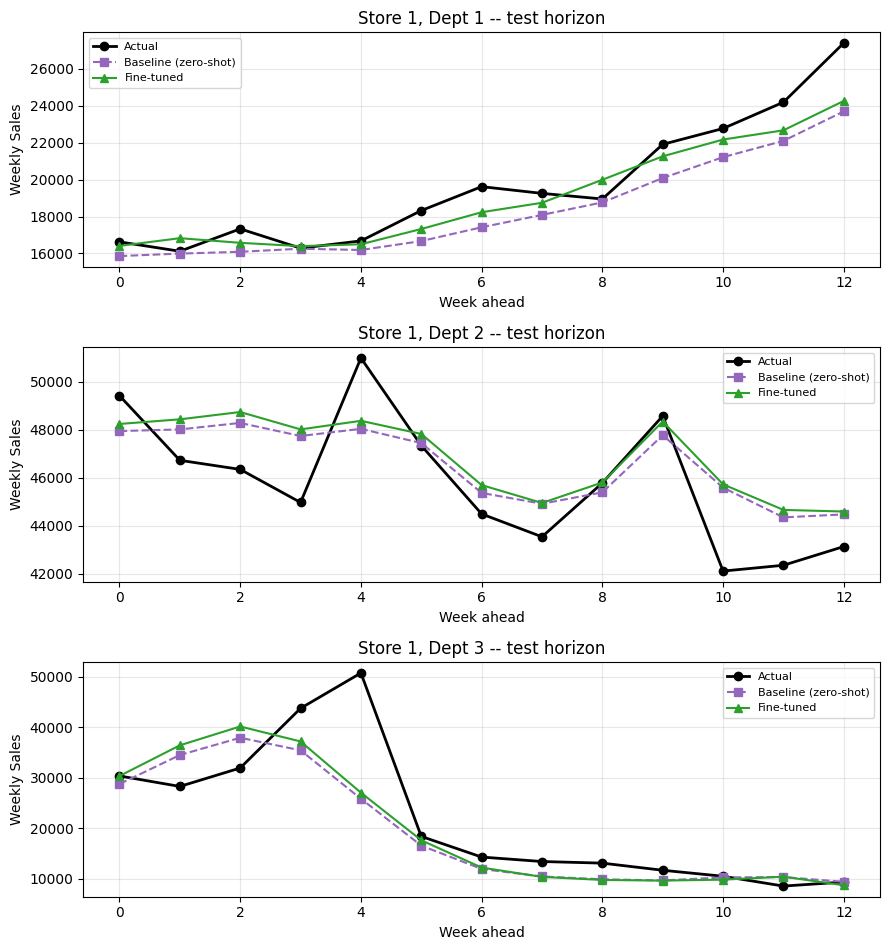

In [16]:
# 9d. Sample actual vs. predicted overlays (baseline vs fine-tuned) on the TEST horizon --
# the true final holdout, for a couple of series.
sample_idx = list(range(min(3, len(keys))))
fig, axes = plt.subplots(len(sample_idx), 1, figsize=(9, 3.2 * len(sample_idx)), squeeze=False)

for row, i in enumerate(sample_idx):
    k = keys[i]
    ax = axes[row][0]
    horizon_x = np.arange(cfg.HORIZON)
    ax.plot(horizon_x, test_actuals[k], marker="o", label="Actual", color="black", linewidth=2)
    ax.plot(horizon_x, test_preds[i], marker="s", label="Baseline (zero-shot)", color="#9467bd", linestyle="--")
    ax.plot(horizon_x, ft_test_preds[i], marker="^", label="Fine-tuned", color="#2ca02c")
    ax.set_title(f"Store {k[0]}, Dept {k[1]} -- test horizon")
    ax.set_xlabel("Week ahead")
    ax.set_ylabel("Weekly Sales")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("sample_forecasts.png", dpi=150)
wandb.log({"plots/sample_forecasts": wandb.Image(fig)})
plt.show()


## 10. Talking points: baseline vs. fine-tuned

In [17]:
def pct_improve(baseline, new):
    return 100 * (baseline - new) / baseline

train_improve = pct_improve(baseline_train_wmae, finetuned_train_wmae)
val_improve = pct_improve(baseline_val_wmae, finetuned_val_wmae)
test_improve = pct_improve(baseline_test_wmae, finetuned_test_wmae)

baseline_val_gap = baseline_val_wmae - baseline_train_wmae
finetuned_val_gap = finetuned_val_wmae - finetuned_train_wmae
baseline_test_gap = baseline_test_wmae - baseline_train_wmae
finetuned_test_gap = finetuned_test_wmae - finetuned_train_wmae

# Did val rank the two models the same way test did? (sanity check that val is a trustworthy proxy for test)
val_favors_finetuned = finetuned_val_wmae < baseline_val_wmae
test_favors_finetuned = finetuned_test_wmae < baseline_test_wmae
val_test_agree = val_favors_finetuned == test_favors_finetuned


wandb.summary["train_pct_improvement"] = train_improve
wandb.summary["val_pct_improvement"] = val_improve
wandb.summary["test_pct_improvement"] = test_improve
wandb.summary["baseline_val_gap"] = baseline_val_gap
wandb.summary["finetuned_val_gap"] = finetuned_val_gap
wandb.summary["baseline_test_gap"] = baseline_test_gap
wandb.summary["finetuned_test_gap"] = finetuned_test_gap
wandb.summary["val_test_agree"] = val_test_agree
summary_text = f"Train Improve: {train_improve:.1f}%, Val Improve: {val_improve:.1f}%, Test Improve: {test_improve:.1f}%\n"
wandb.log({"summary_text": wandb.Html(f"<pre>{summary_text}</pre>")})


NameError: name 'baseline_train_wmae' is not defined

In [18]:
wandb.finish()
print("Done. Check the W&B run for logged metrics, plots, and the summary table.")


elapsed_min,▁▃▄▆█
epoch,▁▃▅▆█
train_loss,█▇▄▂▁
val_wmae,▂▁▂▅█
baseline_test_wmae,1377.10236
baseline_val_wmae,1421.13015
elapsed_min,30.9992
epoch,4
train_loss,2051.07054
val_wmae,1431.56582


Done. Check the W&B run for logged metrics, plots, and the summary table.
